<a href="https://colab.research.google.com/github/Valentinekrafft/Machinelearningproject/blob/main/project_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Modern astronomy is increasingly driven by large-scale observational datasets that contain information on millions or even billions of celestial objects. Among the most important of these surveys, the Gaia mission of the European Space Agency has produced one of the richest astronomical catalogs ever assembled, providing precise measurements of stellar position, motion, brightness, and several derived physical properties for an extraordinary number of stars. Such data offer major opportunities for scientific discovery, but their scale and complexity also make traditional manual analysis difficult.

In this context, machine learning provides a powerful set of tools for extracting structure, identifying patterns, and making predictions from high-dimensional data. In astronomy, these methods are increasingly used to support tasks such as stellar classification, anomaly detection, clustering of stellar populations, and the estimation of physical parameters. Rather than relying only on predefined theoretical categories, machine learning can help reveal hidden organization in the data and quantify how strongly stellar properties are related to one another.

This project focuses on Gaia Data Release 3 and investigates the following research question:
**How effectively can machine learning classify stellar types using Gaia DR3 features, and what structure emerges from clustering in high-dimensional stellar data?**

 More specifically, the aim is to explore whether key Gaia variables such as photometric magnitudes, parallax, proper motion, and derived features like color index and absolute magnitude can be used to uncover meaningful stellar patterns. The project combines exploratory data analysis, supervised learning, and unsupervised learning in order to better understand both the predictive potential and the structural organization of the dataset.

The study first uses exploratory data analysis to examine the distribution, quality, and astrophysical meaning of the selected variables. It then applies machine learning methods to two complementary objectives: predicting or classifying stellar characteristics, and identifying natural groupings of stars without predefined labels. By doing so, the project aims to show how data-driven approaches can contribute to the interpretation of large astronomical surveys and provide insight into the organization of stellar populations.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Gaiadata.csv to Gaiadata.csv


In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Remplacez 'mon_fichier.csv' par le nom de votre fichier téléversé
df = pd.read_csv('Gaiadata.csv')

# Affiche les 5 premières lignes du DataFrame
display(df.head())

,source_id,ra,dec,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,parallax_over_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,bp_g,g_rp,ruwe,teff_gspphot,logg_gspphot,mh_gspphot
0,74698071455360,44.726458,0.511273,-77.832683,0.248792,15.265021,0.213877,14.863120,0.216106,68.77688,18.841656,19.198263,18.469217,0.729046,0.356607,0.372438,0.904749,NaN,NaN,NaN
1,689569884943232,46.310581,2.090590,130.078766,0.158593,47.952369,0.151743,13.654032,0.210791,64.77524,17.710354,20.159250,16.309729,3.849522,2.448896,1.400625,0.900002,NaN,NaN,NaN
2,1240631368988288,43.747435,1.985125,-29.843897,0.018951,-160.086756,0.016044,14.787356,0.017554,842.36950,12.994784,14.045844,11.977854,2.067990,1.051060,1.016931,1.026141,3457.7441,4.0027,-1.4478
3,2058736739430272,43.784164,3.486814,29.687645,0.034472,-12.863435,0.026998,11.645760,0.026301,442.78342,6.855546,6.993539,6.598495,0.395044,0.137993,0.257051,1.150904,7192.2485,3.9894,-0.3228
4,2122130457061248,45.254464,3.830544,160.689758,0.032488,-179.243943,0.024949,10.622672,0.030175,352.03464,14.860165,16.275990,13.694584,2.581406,1.415825,1.165581,1.147289,3477.5440,4.7985,-0.0385


In [ ]:
print("Shape:", df.shape)

df.info()

df.describe()


Shape: (321302, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321302 entries, 0 to 321301
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   source_id            321302 non-null  int64  
 1   ra                   321302 non-null  float64
 2   dec                  321302 non-null  float64
 3   pmra                 321302 non-null  float64
 4   pmra_error           321302 non-null  float64
 5   pmdec                321302 non-null  float64
 6   pmdec_error          321302 non-null  float64
 7   parallax             321302 non-null  float64
 8   parallax_error       321302 non-null  float64
 9   parallax_over_error  321302 non-null  float64
 10  phot_g_mean_mag      320712 non-null  float64
 11  phot_bp_mean_mag     292073 non-null  float64
 12  phot_rp_mean_mag     293108 non-null  float64
 13  bp_rp                291963 non-null  float64
 14  bp_g                 292073 non-null  float64
 1

,source_id,ra,dec,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,parallax_over_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,bp_g,g_rp,ruwe,teff_gspphot,logg_gspphot,mh_gspphot
count,3.213020e+05,321302.000000,321302.000000,321302.000000,321302.000000,321302.000000,321302.000000,321302.000000,321302.000000,321302.000000,320712.000000,292073.000000,293108.000000,291963.000000,292073.000000,292712.000000,321302.000000,102078.000000,102078.000000,102078.000000
mean,3.705252e+18,198.162193,-5.507701,-2.583081,0.409581,-32.187921,0.339113,14.598000,0.430132,414.789619,16.007446,16.856776,14.536075,2.335371,1.204313,1.131760,1.097804,4148.917614,4.652563,-0.233387
std,1.901477e+18,98.666772,37.734428,111.057405,0.664073,103.688204,0.561685,7.730881,0.706969,497.571730,3.555550,3.686986,3.287415,0.949214,0.717508,0.376094,0.122705,1079.569484,0.310242,0.365378
min,4.188882e+13,0.002565,-89.860932,-4406.469179,0.004648,-5817.800194,0.005850,10.000005,0.007861,5.000007,2.303412,3.742892,2.003208,-2.607842,-4.309258,-1.739666,0.485264,2568.129600,1.851900,-4.096500
25%,2.084993e+18,114.234526,-32.642627,-37.834132,0.022229,-64.276029,0.020059,10.969577,0.021766,32.499050,13.951775,14.938004,12.592027,1.664040,0.572704,0.988193,1.011736,3376.594200,4.508600,-0.404000
50%,4.058789e+18,223.457847,-11.109764,-4.979150,0.051753,-11.630543,0.047114,12.470450,0.050664,257.873330,16.103791,17.344358,14.567896,2.494975,1.302293,1.201701,1.075518,3632.930400,4.671800,-0.200900
75%,5.337785e+18,270.904676,22.940813,33.915491,0.400075,5.028416,0.357597,15.466894,0.381165,642.835575,19.386873,19.981405,17.150874,3.000188,1.715021,1.332620,1.172449,4873.910250,4.884300,-0.012900
max,6.917517e+18,359.999926,89.637596,6765.995136,3.336283,10362.394207,3.397606,768.066539,4.798706,15400.477000,21.247400,24.670572,22.341988,6.606365,4.382757,5.068744,1.399986,17682.215000,5.339600,0.799500


In [ ]:
missing = df.isna().mean().sort_values(ascending=False)
print(missing)

teff_gspphot           0.682299
logg_gspphot           0.682299
mh_gspphot             0.682299
bp_rp                  0.091313
phot_bp_mean_mag       0.090970
bp_g                   0.090970
g_rp                   0.088982
phot_rp_mean_mag       0.087749
phot_g_mean_mag        0.001836
dec                    0.000000
ra                     0.000000
source_id              0.000000
pmra                   0.000000
parallax_over_error    0.000000
parallax_error         0.000000
parallax               0.000000
pmdec                  0.000000
pmra_error             0.000000
pmdec_error            0.000000
ruwe                   0.000000
dtype: float64


Due to the high proportion of missing values in the effective temperature variable (~68%), a filtered subset of the dataset is used for supervised learning tasks. Only stars with available temperature measurements are retained for prediction models.


# Dataset and Variables

The dataset used in this study is derived from Gaia Data Release 3, which provides high-precision astrometric and photometric measurements for a large number of stars. In order to conduct the analysis, a subset of relevant variables was selected based on their physical meaning and their usefulness for machine learning tasks such as clustering and prediction.

The selected variables can be grouped into three main categories: astrometric features, photometric features, and derived features.

⸻

Astrometric variables

Astrometric variables describe the position and motion of stars in space.

	•	ra (Right Ascension) and dec (Declination)**
These variables represent the position of a star on the celestial sphere. Although they are not directly used in the main models, they provide spatial context and can be useful for exploratory analysis.

	•	parallax
Parallax measures the apparent shift of a star due to Earth’s motion and is used to estimate the distance to the star. Only positive parallaxes were retained, as negative values are not physically meaningful and correspond to measurement noise.

	•	parallax_over_error
This variable represents the signal-to-noise ratio of the parallax measurement. It was used as a quality filter to ensure reliable distance estimation by retaining only observations with sufficient precision.

	•	pmra and pmdec
These variables describe the proper motion of stars in the sky, capturing their movement in right ascension and declination. They provide information about stellar kinematics and are relevant for clustering analysis.

	•	ruwe (Renormalized Unit Weight Error)
This parameter measures the quality of the astrometric solution. Observations with ruwe < 1.4 were retained to ensure reliable measurements, following common practices in Gaia-based studies.

⸻

##Photometric variables

Photometric variables describe the brightness of stars in different wavelength bands.

	•	phot_g_mean_mag
The apparent magnitude of the star in the G-band, representing its observed brightness.

	•	phot_bp_mean_mag and phot_rp_mean_mag
These correspond to the blue and red photometric bands. They are essential for computing color indices, which are strongly related to stellar temperature.

These variables are fundamental for constructing the Hertzsprung-Russell diagram and for understanding the physical properties of stars.

⸻

Derived features

Several new variables were created to enhance the analysis and better capture astrophysical relationships.

	•	bp_rp (color index)
Computed as the difference between blue and red magnitudes. This is a key feature in astrophysics, as it is strongly correlated with stellar temperature and spectral type.

	•	distance
Estimated from the parallax as an approximation of the distance in parsecs. This allows us to correct for observational biases related to distance.

	•	pm_total
The total proper motion, computed as the Euclidean combination of pmra and pmdec. It provides a single measure of stellar motion.

	•	abs_mag (absolute magnitude)
This variable represents the intrinsic brightness of a star, corrected for distance using parallax. Unlike apparent magnitude, it reflects the true luminosity of the star and is essential for constructing a physically meaningful Hertzsprung-Russell diagram.

⸻

##Target variable

	•	teff_gspphot (effective temperature)
This variable represents the effective temperature of the star and is used as the target variable for supervised learning tasks. Due to a high proportion of missing values, a filtered subset of the dataset was used for temperature prediction.

⸻

##Summary

The selection of these variables allows for a comprehensive analysis of stellar properties, combining spatial information, motion, brightness, and derived physical characteristics. This combination is particularly well-suited for both supervised and unsupervised machine learning tasks, enabling the identification of patterns, clustering of stellar populations, and prediction of key astrophysical properties

In [ ]:
# --- CLEANING ---

# 1. Remove invalid parallaxes
df = df[df["parallax"] > 0]

# 2. Keep reliable astrometry (RUWE filter)
df = df[df["ruwe"] < 1.4]

# 3. Keep precise distance measurements
df = df[df["parallax_over_error"] > 10]


print("Shape after cleaning:", df.shape)

Shape after cleaning: (266536, 20)


In [ ]:
# Color index (very important in astrophysics)
df["bp_rp"] = df["phot_bp_mean_mag"] - df["phot_rp_mean_mag"]

# Distance in parsecs
df["distance"] = 1000 / df["parallax"]

# Total proper motion
df["pm_total"] = np.sqrt(df["pmra"]**2 + df["pmdec"]**2)

# Absolute magnitude (key variable)
df["abs_mag"] = df["phot_g_mean_mag"] + 5 * np.log10(df["parallax"] / 1000) + 5

# Data cleaning and feature engineering

In order to ensure the quality and reliability of the analysis, several preprocessing steps were applied to the dataset. First, stars with non-positive parallax values were removed, as these do not correspond to physically meaningful distances and are typically the result of measurement noise.

To further improve the reliability of the astrometric measurements, a filter based on the Renormalized Unit Weight Error (RUWE) was applied, keeping only observations with ruwe < 1.4. This threshold is commonly used in Gaia-based studies to exclude poorly fitted astrometric solutions.

In addition, a constraint on the parallax signal-to-noise ratio was introduced by selecting only stars with parallax_over_error > 10. This ensures that the estimated distances are sufficiently precise, while maintaining a large enough sample for analysis.

Following the cleaning step, several derived features were created to better capture the physical properties of stars. The color index (bp_rp) was computed as the difference between the blue and red photometric magnitudes, providing a strong proxy for stellar temperature. The distance was estimated from the parallax, and the total proper motion was calculated by combining motion in right ascension and declination.

Finally, the absolute magnitude was derived from the apparent magnitude and parallax. Unlike apparent magnitude, which depends on distance, absolute magnitude represents the intrinsic brightness of a star and is therefore essential for physically meaningful comparisons.



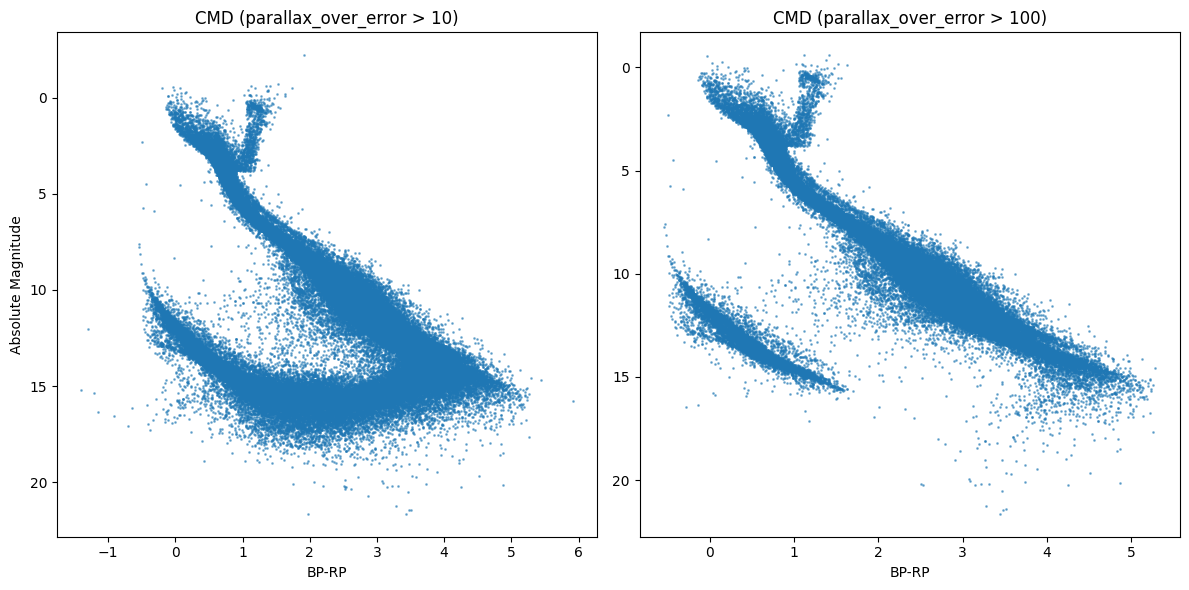

In [ ]:
import matplotlib.pyplot as plt

# Dataset avec seuil 10
df_10 = df[df["parallax_over_error"] > 10]

# Dataset avec seuil 100
df_100 = df[df["parallax_over_error"] > 100]

# Figure avec 2 graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# --- Plot 1 : threshold 10 ---
axes[0].scatter(df_10["bp_rp"], df_10["abs_mag"], s=1, alpha=0.5)
axes[0].invert_yaxis()
axes[0].set_title("CMD (parallax_over_error > 10)")
axes[0].set_xlabel("BP-RP")
axes[0].set_ylabel("Absolute Magnitude")

# --- Plot 2 : threshold 100 ---
axes[1].scatter(df_100["bp_rp"], df_100["abs_mag"], s=1, alpha=0.5)
axes[1].invert_yaxis()
axes[1].set_title("CMD (parallax_over_error > 100)")
axes[1].set_xlabel("BP-RP")

plt.tight_layout()
plt.show()

To evaluate the impact of data quality on the analysis, different thresholds were tested for the parallax signal-to-noise ratio. A stricter threshold (parallax_over_error > 100) produces a cleaner Color-Magnitude Diagram with reduced noise, but significantly reduces the diversity of the dataset. In contrast, a more moderate threshold (parallax_over_error > 10) preserves a larger number of stars and reveals richer stellar structures.

For this reason, the threshold of parallax_over_error > 10 was selected for the main analysis, as it provides a better balance between data quality and representativeness, which is essential for machine learning tasks such as clustering.



#Color-Magnitude Diagram

To explore the structure of the dataset, a Color-Magnitude Diagram (CMD) was constructed using the color index (bp_rp) and the absolute magnitude. This type of diagram is an observational approximation of the classical Hertzsprung-Russell (HR) diagram. While the HR diagram uses stellar temperature and luminosity, the CMD relies on observable quantities derived from photometric measurements.

The resulting diagram reveals several well-defined stellar populations. A prominent diagonal structure, known as the main sequence, is clearly visible and represents the majority of stars. This structure highlights the strong relationship between stellar color and intrinsic brightness.

In the upper-right region of the diagram, a group of stars with high luminosity and red color can be observed, corresponding to red giants. These stars are larger and more evolved. In contrast, a smaller group of faint but relatively blue stars appears in the lower-left region, likely corresponding to white dwarfs, which represent later stages of stellar evolution.

The presence of these well-known astrophysical structures confirms both the quality of the data and the relevance of the selected features. It also demonstrates that meaningful patterns naturally emerge in the data, even before applying machine learning methods. This observation supports the use of clustering algorithms to identify these stellar populations automatically.

In [ ]:
df_close = df[df["distance"] < 100]

In [ ]:
df_close["bp_g"] = df_close["phot_bp_mean_mag"] - df_close["phot_g_mean_mag"]
df_close["g_rp"] = df_close["phot_g_mean_mag"] - df_close["phot_rp_mean_mag"]

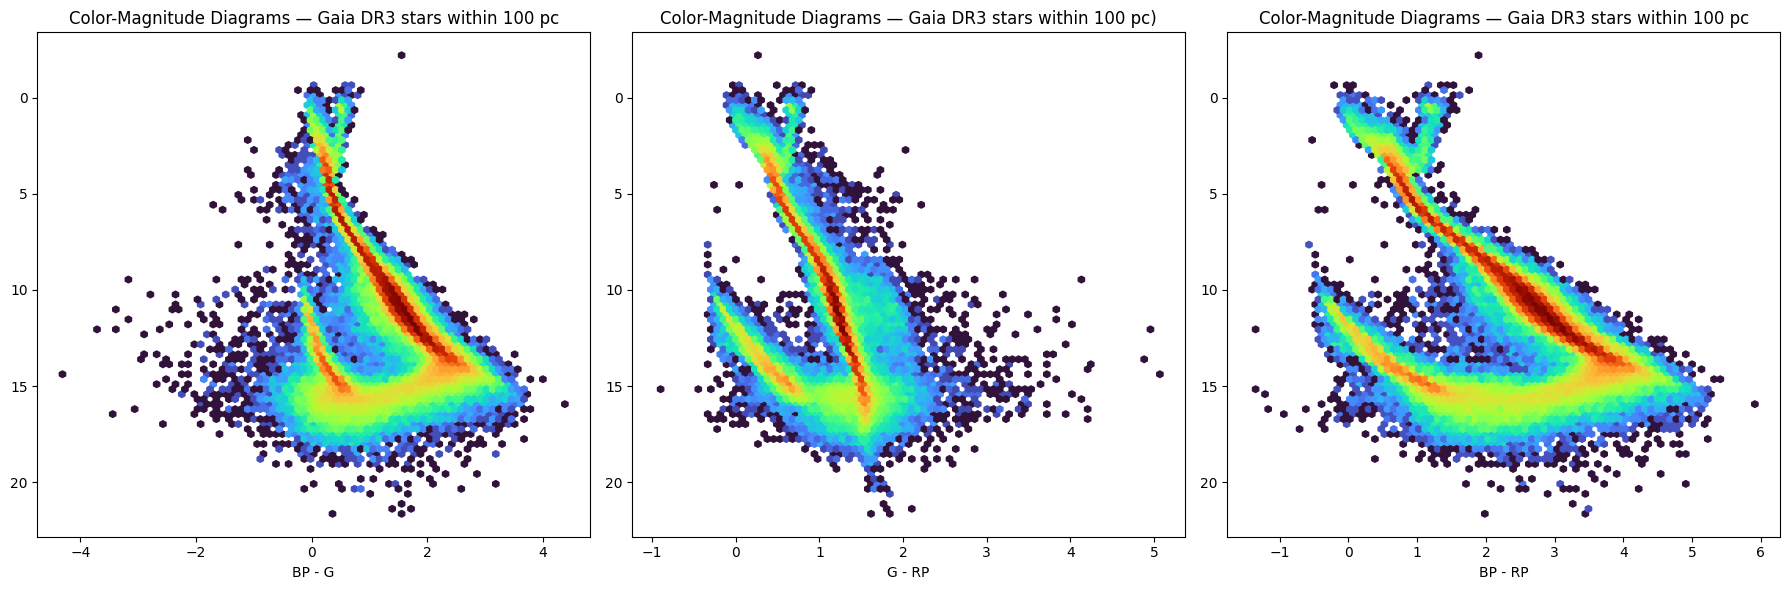

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,6))

# --- BP - G ---
hb1 = axes[0].hexbin(
    df_close["bp_g"],
    df_close["abs_mag"],
    gridsize=80,
    cmap="turbo",
    bins="log",
    mincnt=1
)
axes[0].invert_yaxis()
axes[0].set_title("Color-Magnitude Diagrams — Gaia DR3 stars within 100 pc")
axes[0].set_xlabel("BP - G")

# --- G - RP ---
hb2 = axes[1].hexbin(
    df_close["g_rp"],
    df_close["abs_mag"],
    gridsize=80,
    cmap="turbo",
    bins="log",
    mincnt=1
)
axes[1].invert_yaxis()
axes[1].set_title("Color-Magnitude Diagrams — Gaia DR3 stars within 100 pc)")
axes[1].set_xlabel("G - RP")

# --- BP - RP ---
hb3 = axes[2].hexbin(
    df_close["bp_rp"],
    df_close["abs_mag"],
    gridsize=80,
    cmap="turbo",
    bins="log",
    mincnt=1
)
axes[2].invert_yaxis()
axes[2].set_title("Color-Magnitude Diagrams — Gaia DR3 stars within 100 pc")
axes[2].set_xlabel("BP - RP")

plt.tight_layout()
plt.show()

## Comparison of Color–Magnitude Diagrams

To investigate the structure of stellar populations, three color–magnitude diagrams were constructed using different photometric color indices: BP−RP, G−RP, and BP−G. Each index captures distinct aspects of the stellar spectral energy distribution and therefore provides complementary information about stellar properties.

Across all three diagrams, a consistent global structure emerges. The main sequence is clearly visible as a dense diagonal band extending from hot, luminous stars (low color index, high temperature) to cool, faint stars (high color index). This sequence represents the dominant stellar population in the solar neighbourhood. In addition, secondary populations are systematically observed, including a well-separated white dwarf sequence at low luminosities and a distinct giant branch at higher luminosities.

Despite these shared structures, notable differences appear between the three color indices. The BP−RP index, spanning the full optical range, produces the most extended and continuous representation of the main sequence, making it particularly suitable for capturing global stellar trends. The G−RP index compresses the color range and enhances the separation between stellar populations, especially between white dwarfs and the lower main sequence. In contrast, the BP−G index provides stronger sensitivity to temperature variations in hotter stars and reveals finer details in the upper regions of the diagram, including the bifurcation of evolved stellar populations such as the red giant branch and asymptotic giant branch.

These observations highlight the complementary nature of the different color indices. While each index individually captures the overall structure of the stellar population, their combination provides a richer and more discriminative representation of the data. This suggests that incorporating multiple color indices as input features in machine learning models will improve their ability to classify and characterize stellar populations.

# Univaries Analysis

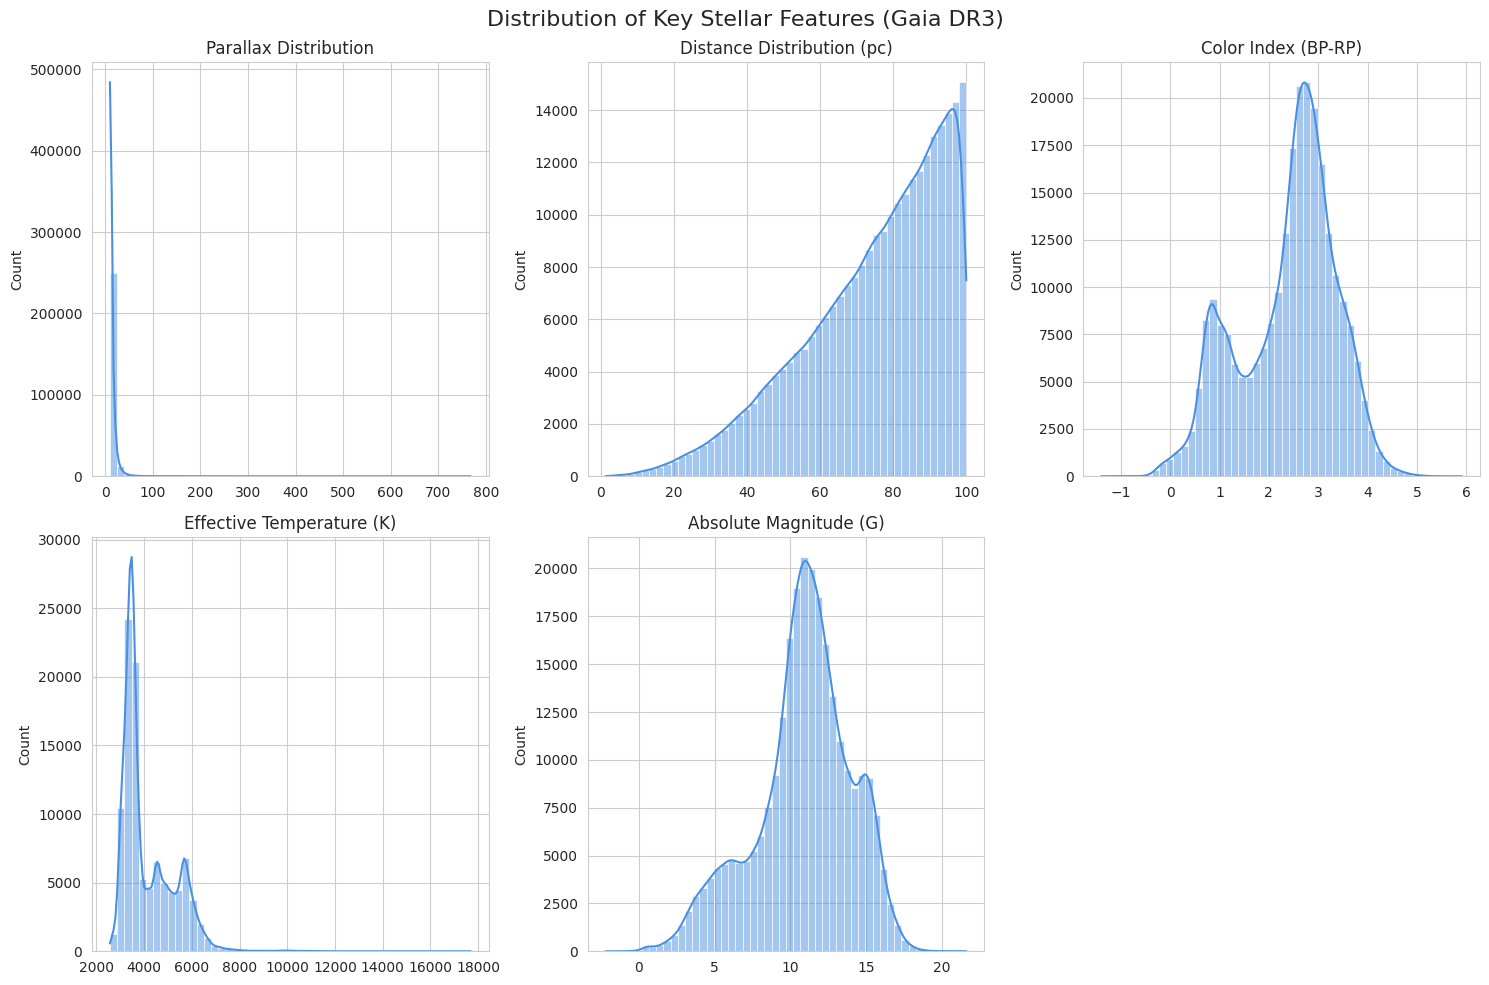

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style global (très important)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,8)

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

variables = ["parallax", "distance", "bp_rp", "teff_gspphot", "abs_mag"]

titles = [
    "Parallax Distribution",
    "Distance Distribution (pc)",
    "Color Index (BP-RP)",
    "Effective Temperature (K)",
    "Absolute Magnitude (G)"
]

for i, var in enumerate(variables):
    sns.histplot(
        df[var],
        bins=50,
        kde=True,              # courbe lissée
        color="#4A90E2",       # bleu propre
        ax=axes[i]
    )

    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# enlever le dernier subplot vide
axes[-1].axis("off")

plt.suptitle("Distribution of Key Stellar Features (Gaia DR3)", fontsize=16)
plt.tight_layout()
plt.show()

### **Distribution of Key Stellar Properties**

To better understand the structure of the dataset, we examine the distributions of key astrophysical variables, including parallax, distance, color index (BP−RP), effective temperature, and absolute magnitude.

The parallax distribution is highly skewed toward small values, indicating that most stars in the dataset are relatively distant. This is expected due to observational bias, as larger volumes of space naturally contain more stars.

The corresponding distance distribution exhibits a strong right-skew, with a large concentration of stars at greater distances. This reflects the inverse relationship between parallax and distance, as well as the selection effects inherent to astronomical surveys.

The BP−RP color index shows a broad and structured distribution, with a clear peak corresponding to K and M-type stars. These stars dominate the solar neighbourhood due to their abundance and long lifetimes. The spread of the distribution reflects the diversity of stellar temperatures in the dataset.

The effective temperature distribution is similarly non-uniform, with a strong concentration around 3000–6000 K, corresponding to cooler stars. A smaller number of high-temperature stars are present, forming a long tail toward higher temperatures.

Finally, the absolute magnitude distribution is clearly multimodal, indicating the presence of distinct stellar populations. The main peak corresponds to main-sequence stars, while secondary structures likely represent white dwarfs and evolved stars. This confirms that the dataset contains heterogeneous stellar populations, which is essential for subsequent clustering and classification tasks.

# Bivaries Analysis
Color vs temperature



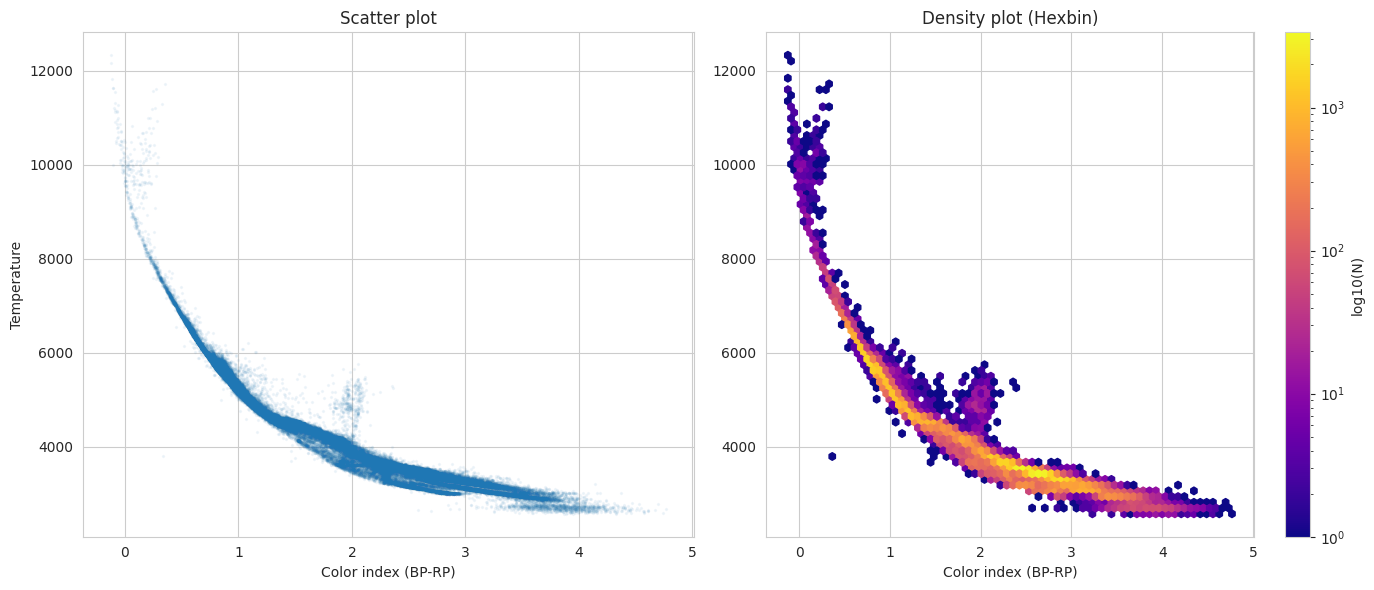

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Filtrer les données pour un rendu propre ---
df_plot = df[
    (df["teff_gspphot"].between(2500, 13000)) &
    (df["bp_rp"].between(-0.5, 4.8))
]

# --- 1. SCATTER ---
axes[0].scatter(
    df_plot["bp_rp"],
    df_plot["teff_gspphot"],
    s=2,
    alpha=0.05
)

axes[0].set_title("Scatter plot")
axes[0].set_xlabel("Color index (BP-RP)")
axes[0].set_ylabel("Temperature")

# --- 2. HEXBIN ---
hb = axes[1].hexbin(
    df_plot["bp_rp"],
    df_plot["teff_gspphot"],
    gridsize=70,
    cmap="plasma",
    mincnt=1,
    bins="log"
)

axes[1].set_title("Density plot (Hexbin)")
axes[1].set_xlabel("Color index (BP-RP)")

# Colorbar
fig.colorbar(hb, ax=axes[1], label="log10(N)")

plt.tight_layout()
plt.show()

The relationship between stellar temperature and color index (BP–RP) is illustrated using both a scatter plot and a density-based hexbin visualization. The scatter plot provides an overview of the distribution of individual observations, while the hexbin plot highlights the density of points and reveals the underlying structure more clearly.

A strong non-linear relationship is observed between the color index and stellar temperature. Stars with low BP–RP values (bluer stars) exhibit significantly higher temperatures, while stars with higher BP–RP values (redder stars) are cooler. This inverse relationship is consistent with well-established astrophysical theory and confirms that the color index is a reliable proxy for stellar temperature.

The hexbin representation further emphasizes regions of high data density, particularly along the main stellar sequence. It also reveals secondary concentrations of stars, which may correspond to distinct stellar populations such as evolved stars or specific evolutionary stages.

Overall, this analysis demonstrates that meaningful physical relationships are present in the dataset and can be effectively captured using simple derived features. These results support the use of machine learning models to predict stellar properties and identify natural groupings in the data.

##Distance vs Apparent Brithness

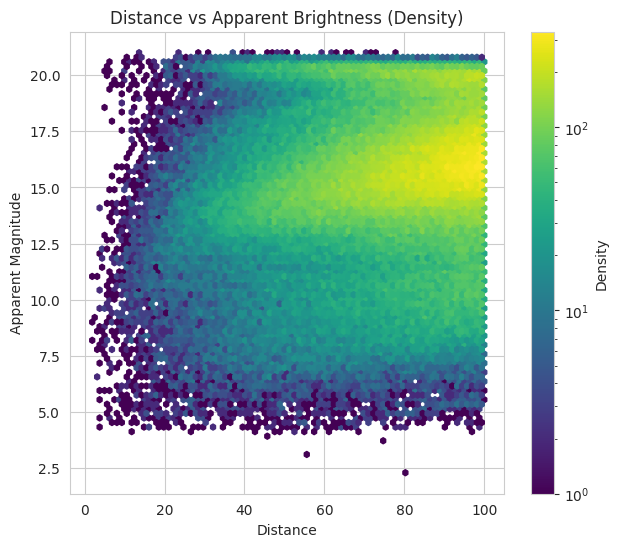

In [ ]:
plt.figure(figsize=(7,6))

plt.hexbin(
    df["distance"],
    df["phot_g_mean_mag"],
    gridsize=80,
    cmap="viridis",
    mincnt=1,
    bins="log"
)

plt.colorbar(label="Density")

plt.xlabel("Distance")
plt.ylabel("Apparent Magnitude")

plt.title("Distance vs Apparent Brightness (Density)")

plt.show()

### **Distance vs Apparent Brightness**

The relationship between distance and apparent magnitude shows a general trend in which more distant stars tend to appear fainter. However, the plot exhibits a high level of dispersion, indicating that apparent brightness alone is not sufficient to describe intrinsic stellar properties.

This variability is due to the fact that stars have very different intrinsic luminosities. As a result, stars at similar distances can exhibit a wide range of apparent magnitudes. Additionally, the presence of an upper boundary in the plot reflects observational limits of the dataset.

These observations highlight the importance of using absolute magnitude, which corrects for distance and provides a more meaningful measure of stellar brightness.



## Correlation matrix

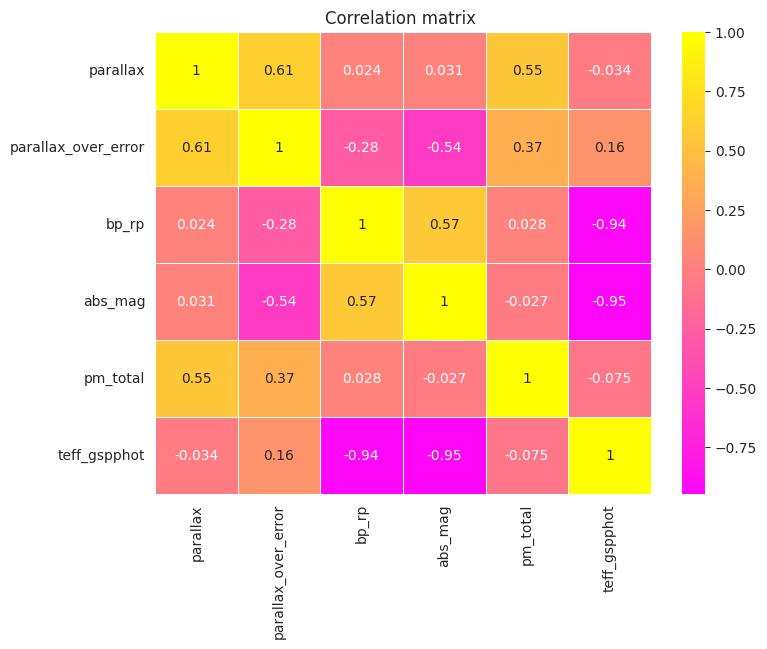

In [ ]:
cols = [
    "parallax",
    "parallax_over_error",
    "bp_rp",
    "abs_mag",
    "pm_total",
    "teff_gspphot"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="spring",   # rose → jaune
    center=0,
    linewidths=0.5
)

plt.title("Correlation matrix ")
plt.show()

### **Correlation analysis**

The correlation matrix reveals strong relationships between key astrophysical variables. In particular, a very strong negative correlation is observed between the color index (bp_rp) and stellar temperature (−0.94), confirming that bluer stars are significantly hotter than redder ones.

Similarly, absolute magnitude is strongly negatively correlated with temperature (−0.95), indicating that more luminous stars tend to be hotter. These strong relationships suggest that both color and intrinsic brightness are highly informative features for predicting stellar temperature.

In contrast, proper motion shows little to no correlation with temperature, which is expected as stellar motion is not directly related to thermal properties.

Overall, these results confirm that the selected features capture meaningful physical relationships and are well-suited for machine learning applications.

# Conclusion EDA

The exploratory data analysis reveals that the dataset exhibits strong non-linear relationships and clear structural patterns. In particular, the color-magnitude diagrams and the temperature–color relationship demonstrate that stellar populations are not randomly distributed but follow well-defined physical sequences.

The presence of distinct groups such as main sequence stars, white dwarfs, and evolved stars suggests that clustering algorithms should be able to identify these populations automatically. Additionally, the strong correlation between color index and temperature indicates that predictive models can effectively estimate stellar properties.

These findings confirm that the selected features are relevant and that the dataset is well-suited for both supervised and unsupervised machine learning tasks.

# PCA:Introduction

In [ ]:
features = ["bp_rp", "abs_mag", "pm_total", "parallax"]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Keep only useful columns for PCA
pca_features = ["bp_rp", "abs_mag", "pm_total", "parallax"]
df_pca = df[pca_features + ["teff_gspphot"]].dropna().copy()

# Optional: reduce extreme outliers for cleaner visualization
df_pca = df_pca[
    (df_pca["bp_rp"].between(-0.5, 5.0)) &
    (df_pca["abs_mag"].between(-2, 20)) &
    (df_pca["parallax"] > 0)
]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[pca_features])

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Store components
df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance (PC1 + PC2):", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.49681483 0.39534547]
Total explained variance (PC1 + PC2): 0.8921603048933724


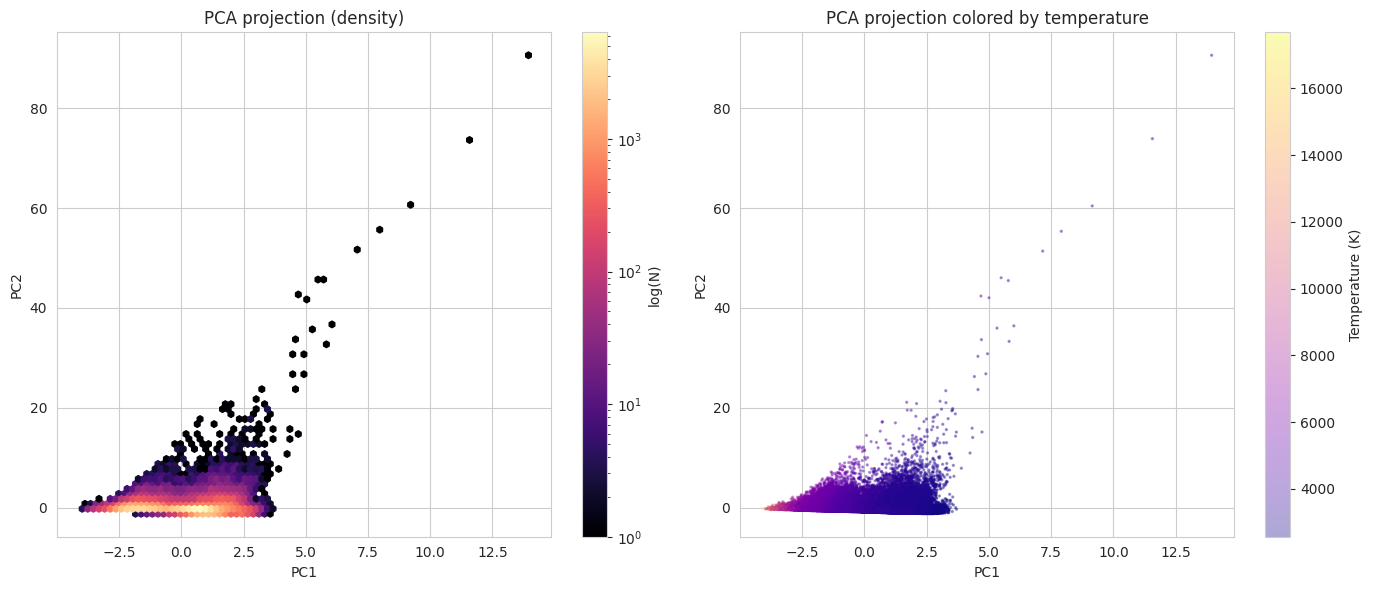

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Density PCA
hb = axes[0].hexbin(
    df_pca["PC1"],
    df_pca["PC2"],
    gridsize=80,
    cmap="magma",
    bins="log",
    mincnt=1
)
axes[0].set_title("PCA projection (density)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(hb, ax=axes[0], label="log(N)")

# PCA colored by temperature
sc = axes[1].scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["teff_gspphot"],
    s=2,
    alpha=0.35,
    cmap="plasma"
)
axes[1].set_title("PCA projection colored by temperature")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
fig.colorbar(sc, ax=axes[1], label="Temperature (K)")

plt.tight_layout()
plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=pca_features
)

print(loadings)

               PC1       PC2
bp_rp     0.699704 -0.101253
abs_mag   0.701583 -0.085816
pm_total  0.112021  0.697613
parallax  0.075143  0.704074


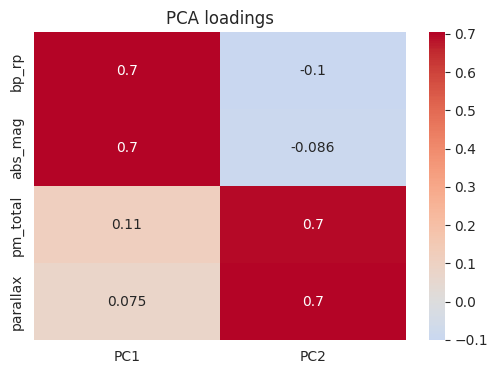

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("PCA loadings")
plt.show()

A Principal Component Analysis (PCA) was performed to explore the structure of the dataset. The loadings indicate that the first principal component is primarily driven by color index (bp_rp) and absolute magnitude, suggesting that it captures the main physical properties of stars, such as temperature and luminosity.

In contrast, the second principal component is dominated by parallax and total proper motion, indicating that it reflects spatial and kinematic properties of stars rather than intrinsic stellar characteristics.

The PCA projection reveals a dense and continuous distribution of points, with no clearly separated clusters. However, the data is not randomly distributed, and a clear structure can be observed.

When coloring the PCA projection by effective temperature, a smooth gradient emerges, confirming that the PCA captures meaningful physical information. This suggests that the underlying stellar properties vary continuously rather than forming distinct groups.

Overall, these results demonstrate that the dataset contains structured information, which can be leveraged by machine learning models. The absence of clearly separated clusters also motivates the use of unsupervised learning methods to further investigate potential groupings.

**supervised learning**

regression:

In [ ]:
df_10.columns

Index(['source_id', 'ra', 'dec', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error',
       'parallax', 'parallax_error', 'parallax_over_error', 'phot_g_mean_mag',
       'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp', 'bp_g', 'g_rp', 'ruwe',
       'teff_gspphot', 'logg_gspphot', 'mh_gspphot', 'distance', 'pm_total',
       'abs_mag'],
      dtype='object')

In [ ]:
corr_target = df_10.corr()['teff_gspphot'].sort_values(ascending=False)
print(corr_target)

teff_gspphot           1.000000
parallax_over_error    0.155786
mh_gspphot             0.041802
pmdec                  0.033658
source_id              0.002773
dec                   -0.002128
pmra                  -0.004179
ra                    -0.007592
parallax              -0.033994
distance              -0.053537
pm_total              -0.074981
ruwe                  -0.300495
parallax_error        -0.309561
pmra_error            -0.309677
pmdec_error           -0.318917
logg_gspphot          -0.714056
phot_rp_mean_mag      -0.894107
phot_g_mean_mag       -0.907178
bp_g                  -0.908027
phot_bp_mean_mag      -0.915159
bp_rp                 -0.937431
abs_mag               -0.946684
g_rp                  -0.969449
Name: teff_gspphot, dtype: float64


code a garder:

In [ ]:
#a garder
threshold = 0.7
selected = corr_target[abs(corr_target) > threshold].index

df_reg = df_10[selected].copy()
df_reg.columns


Index(['teff_gspphot', 'logg_gspphot', 'phot_rp_mean_mag', 'phot_g_mean_mag',
       'bp_g', 'phot_bp_mean_mag', 'bp_rp', 'abs_mag', 'g_rp'],
      dtype='object')

In [ ]:
missing = df_reg.isna().mean().sort_values(ascending=False)
print(missing)

teff_gspphot        0.617024
logg_gspphot        0.617024
bp_rp               0.038306
phot_bp_mean_mag    0.038182
bp_g                0.038182
g_rp                0.037804
phot_rp_mean_mag    0.037128
phot_g_mean_mag     0.000987
abs_mag             0.000987
dtype: float64


tri de df reg (a garder)

In [ ]:
# a garder
# 1. Corrélation avec la target
corr_target = df_10.corr()['teff_gspphot']

# 2. Sélection des variables fortement corrélées (valeur absolue)
threshold = 0.7
selected = corr_target[abs(corr_target) > threshold].index.tolist()

# 3. Création du dataframe de travail
df_reg = df_10[selected].copy()

# 4. Suppression des variables problématiques
if 'logg_gspphot' in df_reg.columns:
    df_reg = df_reg.drop(columns=['logg_gspphot'])

# 5. Suppression des lignes sans target
df_reg = df_reg[df_reg['teff_gspphot'].notna()]

# 6. Suppression des autres NaN
df_reg = df_reg.dropna()

# 7. Vérification finale
print("Colonnes utilisées :", df_reg.columns)
print("Shape finale :", df_reg.shape)

Colonnes utilisées : Index(['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp',
       'bp_g', 'g_rp', 'teff_gspphot', 'abs_mag'],
      dtype='object')
Shape finale : (102076, 8)


In [ ]:
df_reg1 = df_reg[['teff_gspphot', 'g_rp', 'abs_mag']]

regression.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# 1. Séparer X (features) et y (target)
X = df_reg1[['g_rp', 'abs_mag']]
y = df_reg1['teff_gspphot']

# 2. Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Modèle
model = LinearRegression()

# 4. Entraînement
model.fit(X_train, y_train)

# 5. Prédictions
y_pred = model.predict(X_test)

# 6. Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("R² :", r2)

# 7. Coefficients (très important pour ton projet)
print("Coefficients :", model.coef_)
print("Intercept :", model.intercept_)

RMSE : 259.89520654891993
R² : 0.9421143770274409
Coefficients : [-3290.2730384    -10.82551456]
Intercept : 7371.435555194186


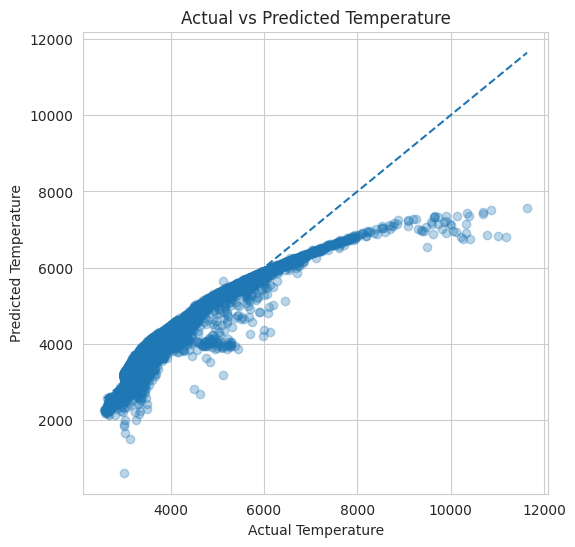

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)

# Ligne parfaite (y = x)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

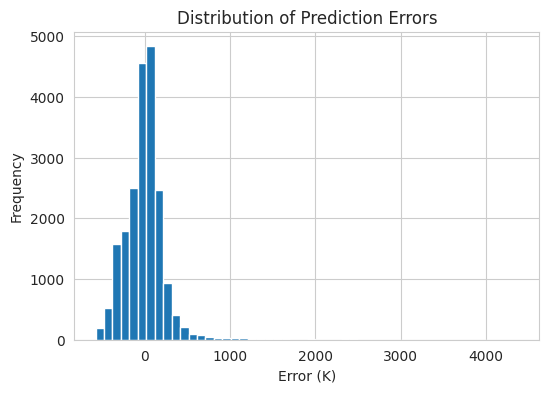

In [ ]:
errors = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.xlabel("Error (K)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()

In this project, we first aimed to identify the most relevant variables to predict the effective temperature of stars (teff_gspphot). To achieve this, we performed a correlation analysis between the target variable and all available features. This step allowed us to highlight the variables most strongly related to temperature, particularly color indices and photometric magnitudes.
We then sorted the variables based on the absolute value of their correlation with the target and applied a threshold to retain only the most informative ones. However, this initial selection revealed the presence of several highly correlated features, especially among photometric measurements, which introduced redundancy.
To address this issue and avoid multicollinearity— which can make the model unstable and harder to interpret — we reduced the number of variables by selecting only a few representative features. In particular, we retained the color index g_rp, which shows a very strong correlation with temperature, and the absolute magnitude abs_mag, which provides complementary information.
Finally, we built a first linear regression model using these selected features. This simple model achieves strong predictive performance while remaining physically interpretable.

parler de g_rp?? dans EDA?

In [ ]:
df_reg2 = df_reg[['teff_gspphot', 'g_rp', 'abs_mag','phot_g_mean_mag' ]]

In [ ]:
#ajouter l'intercept
# Nouvelles variables
X = df_reg2[['g_rp', 'abs_mag', 'phot_g_mean_mag']]
y = df_reg2['teff_gspphot']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modèle
model2 = LinearRegression()
model2.fit(X_train, y_train)

# Prédictions
y_pred2 = model2.predict(X_test)

# Évaluation
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2 = r2_score(y_test, y_pred2)

print("RMSE model 2 :", rmse2)
print("R² model 2 :", r2_2)

# Coefficients
print("Coefficients :", model2.coef_)

RMSE model 2 : 253.9697765984053
R² model 2 : 0.9447237914889117
Coefficients : [-3370.79247167   -75.10131265    71.94818234]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



In [ ]:
# Définition des modèles
models = {
    "Polynomial_deg2": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "Polynomial_deg3": make_pipeline(PolynomialFeatures(3), LinearRegression()),
    "Random_Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient_Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

# Boucle
for name, model in models.items():

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Évaluation
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"RMSE": rmse, "R2": r2}

    print(f"\n{name}")
    print("RMSE :", rmse)
    print("R² :", r2)

# Sélection du meilleur modèle
best_model = min(results, key=lambda x: results[x]["RMSE"])

print("\nBest model :", best_model)


Polynomial_deg2
RMSE : 145.92856178824223
R² : 0.9817503400302786

Polynomial_deg3
RMSE : 128.37200339340242
R² : 0.985877395065081

Random_Forest
RMSE : 114.9648406679809
R² : 0.9886732776196658

Gradient_Boosting
RMSE : 125.67308841576039
R² : 0.9864649847790221

Best model : Random_Forest


Although ensemble models such as Random Forest achieved the best predictive performance, they are considered black-box models, meaning their internal decision process is difficult to interpret. In contrast, polynomial regression provides a more transparent and physically meaningful approach. Given that the relationship between stellar color and temperature is inherently non-linear, a polynomial model is more appropriate than a simple linear regression. It allows us to capture this curvature while still maintaining interpretability. Therefore, a polynomial regression represents a better balance between performance and scientific understanding in this context.

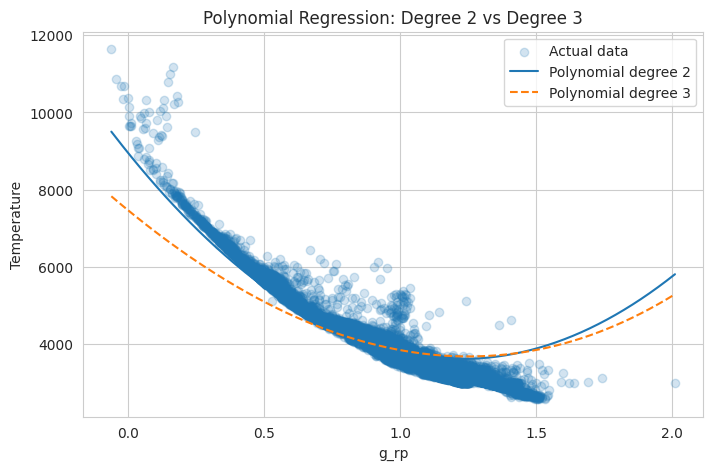

In [ ]:
# Récupérer les modèles déjà entraînés
model_deg2 = models["Polynomial_deg2"]
model_deg3 = models["Polynomial_deg3"]

# Fixer les autres variables à leur moyenne
abs_mag_mean = X_test['abs_mag'].mean()
phot_g_mean = X_test['phot_g_mean_mag'].mean()

# Créer une plage de g_rp
g_rp_range = np.linspace(X_test['g_rp'].min(), X_test['g_rp'].max(), 200)

# Créer dataframe propre
X_plot = pd.DataFrame({
    'g_rp': g_rp_range,
    'abs_mag': abs_mag_mean,
    'phot_g_mean_mag': phot_g_mean
})

# Prédictions
y_plot2 = model_deg2.predict(X_plot)
y_plot3 = model_deg3.predict(X_plot)

# Plot
plt.figure(figsize=(8,5))

# Données réelles
plt.scatter(X_test['g_rp'], y_test, alpha=0.2, label="Actual data")

# Courbes
plt.plot(g_rp_range, y_plot2, label="Polynomial degree 2")
plt.plot(g_rp_range, y_plot3, linestyle='--', label="Polynomial degree 3")

plt.xlabel("g_rp")
plt.ylabel("Temperature")
plt.title("Polynomial Regression: Degree 2 vs Degree 3")
plt.legend()

plt.show()

“The degree 2 polynomial model captures the non-linear relationship between stellar color and temperature more accurately, while the degree 3 model introduces unnecessary complexity and slight overfitting, especially at the extremes.”